# 07 — Regression Training (1-Month Forward Return)

Cross-sectional return prediction for SPI Extra: monthly snapshots, **Information Coefficient (IC)** as the primary metric (Spearman rank correlation between predicted and realized 1M returns), Random Forest / optional XGBoost with expanding-window CV, and **SHAP** for feature importance.

**Features:** 23 technical (momentum, trend, volatility, volume, liquidity, mean-reversion) + 13 fundamental (incl. analyst consensus) + 2 seasonality + cross-sectional rank features. Redundant pairs are removed with `drop_correlated_threshold=0.85` **inside** `train_regressor` (correlations fit on the training split only).

**Pipeline:** load OHLCV → liquidity filter → monthly forward targets → features + ranks at each `cutoff_date` (no lookahead) → train (median imputation + optional corr filter on train split, 3-month hold-out) → IC by month → SHAP → optional full refit and save for notebook 08.


In [ ]:
from __future__ import annotations

import logging
import sys
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import config
from src.data_loader import download_ohlcv, load_fundamentals
from src.features import build_feature_matrix, build_rank_features
from src.regression_model import (
    evaluate_regression,
    plot_feature_importance_regression,
    plot_ic_by_period,
    plot_predicted_vs_actual,
    refit_regressor_full,
    save_regression_model,
    shap_explain_regression,
    train_regressor,
)
from src.regression_targets import compute_monthly_forward_returns
from src.universe import filter_by_min_volume, get_spi_extra_tickers

try:
    from IPython.display import display
except ImportError:
    display = print

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.max_rows", 40)
pd.set_option("display.width", 120)
warnings.filterwarnings("ignore", category=FutureWarning)

# --- Training window (in-sample; 2025 forward-test is notebook 08) ---
TRAIN_START_MONTH = "2022-09"
TRAIN_END_MONTH = "2024-12"

# Set to an int to debug faster (first N tickers after universe filter)
TICKER_LIMIT: int | None = None

# Hyperparameter search is slow; set True for full GridSearchCV on IC
TUNE_HYPERPARAMS = False

# Model: "rf" or "xgb" (see `train_regression_ensemble` in src for RF+XGB blend)
MODEL_TYPE = "rf"

print(f"Project root: {PROJECT_ROOT}")
print(f"yfinance window: {config.YF_START} → {config.YF_END}")
print(f"Training months: {TRAIN_START_MONTH} … {TRAIN_END_MONTH}")
print(f"Random seed: {config.RANDOM_SEED}")


Project root: /Users/stephangath/cursorAi/Stock Analysis AI
yfinance window: 2022-07-01 → 2025-12-31
Training months: 2022-09 … 2024-12
Random seed: 42


## 1 — Universe, OHLCV, fundamentals

Same cache as other notebooks (`data/ohlcv`, `data/fundamentals`). Liquidity filter uses `config.MIN_DAILY_VOLUME_CHF`.


In [2]:
tickers_all = get_spi_extra_tickers()
print(f"SPI Extra tickers (raw): {len(tickers_all)}")

ohlcv_by_ticker = download_ohlcv(
    tickers_all,
    start=config.YF_START,
    end=config.YF_END,
    cache_dir=config.DATA_DIR,
    max_workers=8,
)

passed = filter_by_min_volume(
    ohlcv_by_ticker,
    config.MIN_DAILY_VOLUME_CHF,
)
tickers = passed
if TICKER_LIMIT is not None:
    tickers = tickers[:TICKER_LIMIT]

ohlcv_by_ticker = {t: ohlcv_by_ticker[t] for t in tickers if t in ohlcv_by_ticker}
print(f"After liquidity filter: {len(tickers)} tickers")

fundamentals_by_ticker: dict[str, dict] = {}
with ThreadPoolExecutor(max_workers=8) as pool:
    futs = {pool.submit(load_fundamentals, t, cache_dir=config.DATA_DIR): t for t in tickers}
    for fut in as_completed(futs):
        t = futs[fut]
        try:
            fundamentals_by_ticker[t] = fut.result()
        except Exception as exc:
            fundamentals_by_ticker[t] = {}
            logging.warning("Fundamentals failed for %s: %s", t, exc)
print(f"Fundamentals loaded: {len(fundamentals_by_ticker)} tickers")


SPI Extra tickers (raw): 194


ERROR yfinance: $ACHI.SW: possibly delisted; no timezone found
ERROR yfinance: 
1 Failed download:
ERROR yfinance: ['ACHI.SW']: possibly delisted; no timezone found
ERROR yfinance: HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: AFP.SW"}}}
ERROR yfinance: $AFP.SW: possibly delisted; no timezone found
ERROR yfinance: 
1 Failed download:
ERROR yfinance: ['AFP.SW']: possibly delisted; no timezone found
ERROR yfinance: $AIRE.SW: possibly delisted; no timezone found
ERROR yfinance: 
1 Failed download:
ERROR yfinance: ['AIRE.SW']: possibly delisted; no timezone found
ERROR yfinance: $ARON.SW: possibly delisted; no timezone found
ERROR yfinance: 
1 Failed download:
ERROR yfinance: ['ARON.SW']: possibly delisted; no timezone found
ERROR yfinance: $BALN.SW: possibly delisted; no timezone found
ERROR yfinance: 
1 Failed download:
ERROR yfinance: ['BALN.SW']: possibly delisted; no timezone found
ERROR yfinance: $BLS.SW: possibl

After liquidity filter: 136 tickers
Fundamentals loaded: 136 tickers


## 2 — Monthly 1M forward returns

`compute_monthly_forward_returns` builds rows `(ticker, cutoff_date, forward_1m_return)` with no lookahead: features must use data only through `cutoff_date`.


In [3]:
fwd = compute_monthly_forward_returns(
    ohlcv_by_ticker,
    start_month=TRAIN_START_MONTH,
    end_month=TRAIN_END_MONTH,
)
print(f"Forward return rows: {len(fwd)}")
if not fwd.empty:
    display(fwd.head())
    print("Months:", fwd["date"].dt.to_period("M").nunique())


INFO src.regression_targets: compute_monthly_forward_returns: 3780 rows (28 months × ~135 tickers/row)


Forward return rows: 3780


,ticker,date,cutoff_date,forward_1m_return
0,ADEN.SW,2022-09-30,2022-09-30,0.143378
1,AEVS.SW,2022-09-30,2022-09-30,-0.010582
2,ALLN.SW,2022-09-30,2022-09-30,0.039130
3,ALSN.SW,2022-09-30,2022-09-30,0.069293
4,AMS.SW,2022-09-30,2022-09-30,-0.091258


Months: 28


## 3 — Stacked feature matrix (+ rank features)

For each unique `cutoff_date`, `build_feature_matrix` computes technicals (23), fundamentals (13 incl. analyst consensus), and seasonality (2) using only OHLCV through that date. Cross-sectional **rank features** (`rank_` prefix) are appended per cutoff snapshot. Highly correlated columns are dropped **during training** via `train_regressor(..., drop_correlated_threshold=0.85)` (fit on the training split only).


In [4]:
def build_monthly_regression_panel(
    ohlcv_by_ticker: dict[str, pd.DataFrame],
    forward_returns_df: pd.DataFrame,
    fundamentals_by_ticker: dict,
) -> tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    """Return (X, y, period_label per row as YYYY-MM).

    Rank features (cross-sectional percentile ranks) are computed per
    cutoff snapshot and appended before stacking.
    """
    if forward_returns_df.empty:
        raise ValueError("forward_returns_df is empty")

    fwd = forward_returns_df.sort_values(["cutoff_date", "ticker"]).reset_index(drop=True)
    parts: list[pd.DataFrame] = []
    y_list: list[float] = []
    period_labels: list[str] = []

    for cutoff_ts, group in fwd.groupby("cutoff_date", sort=True):
        cd_str = pd.Timestamp(cutoff_ts).strftime("%Y-%m-%d")
        X_cut = build_feature_matrix(
            ohlcv_by_ticker,
            cutoff_date=cd_str,
            fundamentals_by_ticker=fundamentals_by_ticker,
        )
        X_rank = build_rank_features(X_cut)
        X_cut = pd.concat([X_cut, X_rank], axis=1)

        pmonth = pd.Timestamp(cutoff_ts).strftime("%Y-%m")
        for _, row in group.iterrows():
            t = row["ticker"]
            if t not in X_cut.index:
                continue
            parts.append(X_cut.loc[[t]].copy())
            y_list.append(float(row["forward_1m_return"]))
            period_labels.append(pmonth)

    if not parts:
        return pd.DataFrame(), np.array([]), np.array([])

    X_stacked = pd.concat(parts, axis=0)
    X_stacked.index = pd.RangeIndex(len(X_stacked))
    y_arr = np.asarray(y_list, dtype=float)
    pl_arr = np.asarray(period_labels)
    return X_stacked, y_arr, pl_arr


X_raw, y, period_labels = build_monthly_regression_panel(
    ohlcv_by_ticker,
    fwd,
    fundamentals_by_ticker,
)
if X_raw.empty or len(y) == 0:
    raise RuntimeError(
        "Empty regression panel — check OHLCV coverage, liquidity filter, and TRAIN_* month range."
    )
print(f"Stacked panel: X={X_raw.shape}, y={y.shape}, periods={np.unique(period_labels).size}")
print("(Correlation filter runs inside train_regressor on the training split only.)")
display(X_raw.iloc[:3, :8])


INFO src.features: Feature matrix: 136 tickers x 28 features (NaN rate 12.1%)
INFO src.features: Feature matrix: 136 tickers x 28 features (NaN rate 12.1%)
INFO src.features: Feature matrix: 136 tickers x 28 features (NaN rate 12.1%)
INFO src.features: Feature matrix: 136 tickers x 28 features (NaN rate 8.5%)
INFO src.features: Feature matrix: 136 tickers x 28 features (NaN rate 8.5%)
INFO src.features: Feature matrix: 136 tickers x 28 features (NaN rate 8.5%)
INFO src.features: Feature matrix: 136 tickers x 28 features (NaN rate 8.5%)
INFO src.features: Feature matrix: 136 tickers x 28 features (NaN rate 5.0%)
INFO src.features: Feature matrix: 136 tickers x 28 features (NaN rate 5.0%)
INFO src.features: Feature matrix: 136 tickers x 28 features (NaN rate 5.0%)
INFO src.features: Feature matrix: 136 tickers x 28 features (NaN rate 5.0%)
INFO src.features: Feature matrix: 136 tickers x 28 features (NaN rate 5.0%)
INFO src.features: Feature matrix: 136 tickers x 28 features (NaN rate 5.

Stacked panel: X=(3780, 28), y=(3780,), periods=28


,mom_1m,mom_3m,mom_6m,rsi_14,roc_10,sma_ratio_50_200,macd_diff_norm,adx_14
0,-0.082357,-0.158686,NaN,34.678231,-8.235691,NaN,-0.006805,33.113477
1,-0.035714,0.080000,NaN,47.173918,-10.426544,NaN,-0.005593,19.343988
2,-0.093298,-0.124366,NaN,36.309344,-8.366538,NaN,-0.006732,38.540924


## 4 — Train regressor (3-month hold-out)

`train_regressor` uses **expanding-window CV** on training months when `period_labels` is set. The **last 3 months** (`holdout_periods=3`) are held out for validation, giving more robust IC estimates than a single month. Scoring during tuning is **IC (Spearman)**.

Set `TUNE_HYPERPARAMS = True` for full grid search (slow).


In [5]:
result = train_regressor(
    X_raw,
    y,
    model_type=MODEL_TYPE,
    period_labels=period_labels,
    random_state=config.RANDOM_SEED,
    tune=TUNE_HYPERPARAMS,
    min_train_periods=3,
    holdout_periods=3,
    drop_correlated_threshold=0.85,
)

print("Best params:", result.best_params)
print("CV (expanding window):", result.cv_results)
print("Hold-out metrics:", {k: result.holdout_metrics[k] for k in ("ic", "rmse", "mae", "r2", "n_samples")})
if "ic_mean" in result.holdout_metrics:
    print(f"IC stability (hold-out months): {result.holdout_metrics['ic_mean']:.4f} ± {result.holdout_metrics['ic_std']:.4f}")
    print(f"IC Information Ratio: {result.holdout_metrics.get('ic_ir', float('nan')):.3f}")


INFO src.regression_model: Walk-forward split: 3645 train (27 periods) / 135 test (period 2024-12), 28 features
INFO src.regression_model: Hold-out: IC=0.1187  RMSE=0.1228  MAE=0.0741  R²=-1.5987
INFO src.regression_model: CV: IC=0.0091 ± 0.0881  RMSE=0.1081 ± 0.0583  (24 folds)


Best params: {}
CV (expanding window): {'ic_mean': 0.009141927942960329, 'ic_std': 0.08813220950584469, 'ic_per_fold': [0.17898741586186717, -0.053195069725877765, -0.012423238821915518, -0.026546222985854028, 0.05843583362095069, 0.1293239683933275, -0.10820183892201639, 0.03454801750122797, -0.08389466342243697, 0.12042742223623996, -0.0635872547512736, -0.09049615951640655, 0.005906769616544836, 0.02435871797277036, -0.10239257437400838, 0.07269046922251489, 0.057536200958298936, 0.057728584685176915, 0.22280265339966834, 0.0020998079444343584, -0.02399289821947485, -0.07724162150916929, -0.026226709589308363, -0.07724133894423231], 'rmse_mean': 0.108140988442938, 'rmse_std': 0.05826917457945663, 'rmse_per_fold': [0.12668799408341547, 0.1053760437994379, 0.12043327222004133, 0.09580070923587007, 0.11021262379489097, 0.08540887389419141, 0.10345164202898886, 0.1057450743076405, 0.09140050654058655, 0.08956054342190253, 0.1309240501177814, 0.08226716202364935, 0.09997426350347899, 0.0

## 5 — IC analysis and predicted vs actual

Per-period IC shows whether the signal is stable across months (not just one lucky month).


,period,ic,n
0,2024-12,0.118681,135


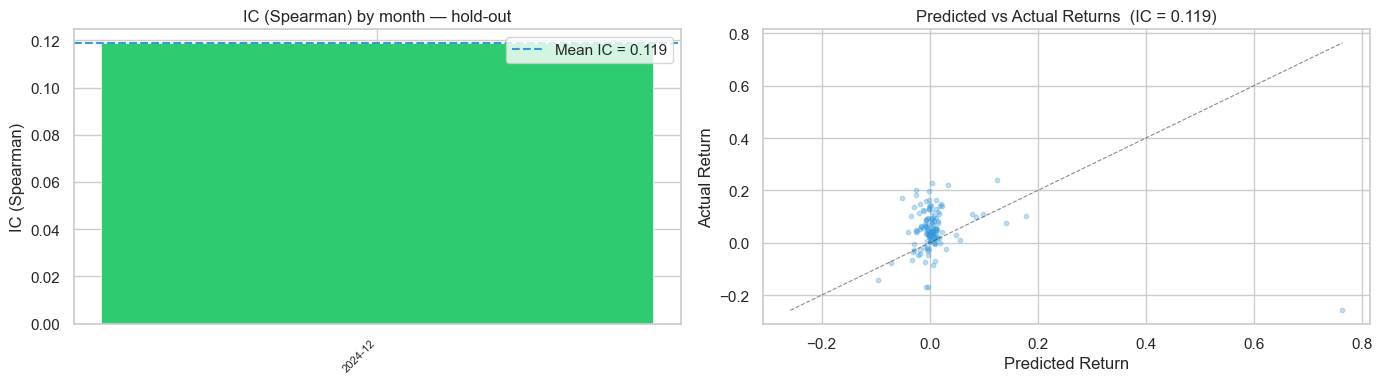

Overall hold-out IC: 0.1187
IC mean (across hold-out months): 0.1187


In [6]:
y_pred_test = result.model.predict(result.X_test.values)
ho = evaluate_regression(
    result.y_test,
    y_pred_test,
    period_labels=result.period_labels_test,
)
ic_df = ho["ic_by_period"]
display(ic_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_ic_by_period(ic_df, title="IC (Spearman) by month — hold-out", ax=axes[0])
plot_predicted_vs_actual(result.y_test, y_pred_test, ax=axes[1])
plt.tight_layout()
plt.show()

print(f"Overall hold-out IC: {ho['ic']:.4f}")
print(f"IC mean (across hold-out months): {ho.get('ic_mean', float('nan')):.4f}")


## 6 — SHAP feature importance

Tree SHAP on the fitted tree model (Random Forest component for ensemble). Uses train + test rows from the training run for explanation.

Feature groups: **technical** (23), **fundamental + analyst** (13), **seasonality** (2), **rank features** (variable, after correlation filter). New features include analyst consensus, liquidity metrics, mean-reversion extensions, and cross-sectional ranks.


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Top features by mean |SHAP|:


atr_14_pct            0.009693
sma_ratio_50_200      0.007761
hvol_20d              0.005346
dist_52w_low          0.004620
market_cap_log        0.004118
bb_width              0.003595
hvol_60d              0.003500
profit_margin         0.003378
pb_ratio              0.003192
roe                   0.002718
mom_3m                0.002646
rel_volume_5d         0.002524
dist_52w_high         0.002255
mom_6m                0.002133
adx_14                0.001892
macd_diff_norm        0.001768
roc_10                0.001580
mom_1m                0.001532
volume_ratio_20_60    0.001492
obv_slope_20d         0.001462
zscore_20d            0.001455
revenue_growth        0.001281
rsi_14                0.000970
ev_ebitda             0.000952
debt_equity           0.000946
Name: mean_abs_shap, dtype: float64

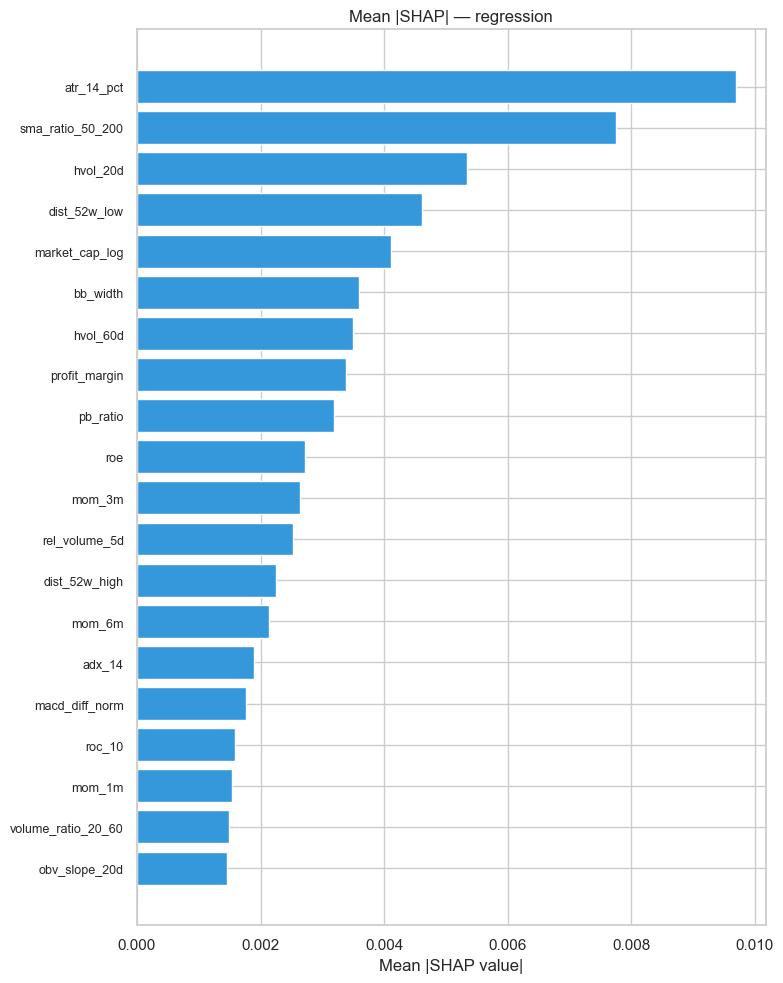

In [7]:
shap_out = shap_explain_regression(result)
print(f"Total features in model: {len(shap_out['feature_names'])}")
print("\nTop features by mean |SHAP|:")
display(shap_out["mean_abs_shap"].head(30))

NEW_FEATURES = {
    "analyst_rating", "analyst_count", "analyst_target_upside",
    "amihud_illiq", "volume_trend_60d", "spread_proxy",
    "month_sin", "month_cos",
    "return_skew_60d", "max_drawdown_60d",
}
new_in_top = [f for f in shap_out["mean_abs_shap"].head(30).index if f in NEW_FEATURES or f.startswith("rank_")]
print(f"\nNew/rank features in top 30 SHAP: {new_in_top}")

fig, ax = plt.subplots(figsize=(9, 12))
plot_feature_importance_regression(
    shap_out["mean_abs_shap"],
    top_n=30,
    title="Mean |SHAP| — regression (expanded features)",
    ax=ax,
)
plt.tight_layout()
plt.show()


## 7 — Refit on full training panel and save

Refits on all months in `TRAIN_*` for use in forward tests (notebook 08). Artifacts go under `data/models/`.


In [8]:
model_dir = config.DATA_DIR / "models"
model_dir.mkdir(parents=True, exist_ok=True)

result_full = refit_regressor_full(X_raw, y, result, random_state=config.RANDOM_SEED)
out_path = model_dir / "regression_model_train.joblib"
save_regression_model(result_full, out_path)
print(f"Saved: {out_path}")


INFO src.regression_model: Refit on full data: 3780 samples × 28 features
INFO src.regression_model: Regression model saved to /Users/stephangath/cursorAi/Stock Analysis AI/data/models/regression_model_train.joblib


Saved: /Users/stephangath/cursorAi/Stock Analysis AI/data/models/regression_model_train.joblib
